In [1]:
import torch.multiprocessing as mp

if __name__ == "__main__":
    mp.set_start_method("spawn", force=True)

from torch import optim
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import torch
import random
import numpy as np
import torch.nn as nn
import albumentations as Albu
import pandas as pd
from torch.utils.data.sampler import RandomSampler
from warmup_scheduler import GradualWarmupScheduler
import os
from utils.dataset import PandasDataset, RGB2Fusion, RGB2FusionTorch
from utils.metrics import model_checkpoint
from utils.train import train_model
from utils.models import EfficientNetApi, EfficientNetApiGem

In [2]:
seed = 42
shuffle = True
batch_size = 4
num_workers = 4
output_classes = 5
init_lr = 3e-4
warmup_factor = 10
warmup_epochs = 1
n_epochs = 50
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
loss_function = nn.BCEWithLogitsLoss()

torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)

ROOT_DIR = '../../..'

data_dir = '../../../../dataset'
images_dir = os.path.join(data_dir, 'tiles')

Using device: cuda


In [3]:
load_model = efficientnet_b0(
     weights=EfficientNet_B0_Weights.DEFAULT
)
model = EfficientNetApi(model=load_model, output_dimensions=output_classes)
model = model.to(device)

In [4]:
print("Using device:", device)
loss_function = nn.BCEWithLogitsLoss()

torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)

Using device: cuda


In [5]:
df_train_ = pd.read_csv(f"{ROOT_DIR}/data/train_5fold.csv")
df_train_.columns = df_train_.columns.str.strip()
train_indexes = np.where((df_train_['fold'] != 3))[0]
valid_indexes = np.where((df_train_['fold'] == 3))[0]
#
df_train = df_train_.loc[train_indexes]
df_val = df_train_.loc[valid_indexes]
df_test = pd.read_csv(f"{ROOT_DIR}/data/test.csv")

#### view data

In [6]:
(df_train.shape, df_val.shape, df_test.shape)

((7219, 5), (1805, 5), (1592, 4))

In [7]:
transforms = Albu.Compose([
    RGB2FusionTorch(mode="mean", space_colors=["rgb", "xyz", "lab"]),
    Albu.Transpose(p=0.5),
    Albu.VerticalFlip(p=0.5),
    Albu.HorizontalFlip(p=0.5),
])

valid_transforms = Albu.Compose([
    RGB2FusionTorch(mode="mean", space_colors=["rgb", "xyz", "lab"])
])

In [8]:
df_train.columns = df_train.columns.str.strip()

train_dataset = PandasDataset(images_dir, df_train, transforms=transforms)
valid_dataset = PandasDataset(images_dir, df_val, transforms=valid_transforms)
test_dataset = PandasDataset(images_dir, df_test, transforms=valid_transforms)

tensor(0.0158)
tensor(1.)


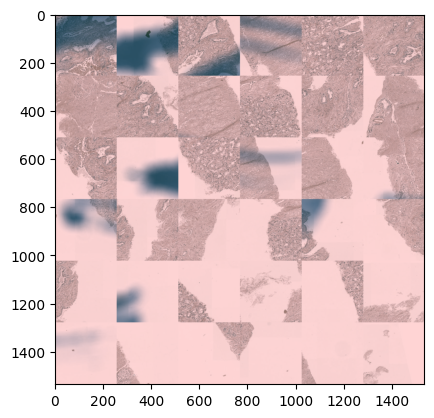

In [9]:
import matplotlib.pyplot as plt
print(train_dataset[0][0].min())
print(train_dataset[0][0].max())

img = train_dataset[0][0].permute(1, 2, 0).numpy()


plt.imshow(img)

In [10]:
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=batch_size, num_workers=num_workers, sampler=RandomSampler(train_dataset)
)
valid_loader = torch.utils.data.DataLoader(
    valid_dataset, batch_size=batch_size, num_workers=num_workers, sampler = RandomSampler(valid_dataset)
)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=batch_size, num_workers=num_workers, sampler = RandomSampler(test_dataset)
)

In [11]:
optimizer = optim.Adam(model.parameters(), lr = init_lr / warmup_factor)
scheduler_cosine = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, n_epochs - warmup_epochs)
scheduler = GradualWarmupScheduler(optimizer, multiplier = warmup_factor, total_epoch = warmup_epochs, after_scheduler=scheduler_cosine)

In [12]:
train_model(
    model=model,
    epochs=n_epochs,
    optimizer=optimizer,
    scheduler=scheduler,
    train_dataloader=train_loader,
    valid_dataloader=valid_loader,
    checkpoint=model_checkpoint,
    device=device,
    loss_function=loss_function,
    path_to_save_metrics="logs/fusion-mean.txt",
    path_to_save_model="models/fusion-mean.pth",
    patience=5,
)

Epoch 1/50



100%|██████████| 452/452 [02:09<00:00,  3.49it/s]


VAL_LOSS     0.332
VAL_ACC      Mean: 44.302 | Std: 1.162 | 95% CI: [42.382, 46.260]
VAL_KAPPA    Mean: 0.745 | Std: 0.012 | 95% CI: [0.725, 0.764]
VAL_F1       Mean: 0.379 | Std: 0.012 | 95% CI: [0.360, 0.398]
VAL_RECALL   Mean: 0.387 | Std: 0.011 | 95% CI: [0.369, 0.405]
VAL_PRECISION Mean: 0.476 | Std: 0.016 | 95% CI: [0.449, 0.501]
Salvando o melhor modelo... 0.0 -> 0.7453468768033706
Epoch 2/50



100%|██████████| 452/452 [02:11<00:00,  3.43it/s]
/home/woshington/Projects/Doutorado/repo/.venv/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:1087: UserWarning: To get the last learning rate computed by the scheduler, please use `get_last_lr()`.
  _warn_get_lr_called_within_step(self)


VAL_LOSS     0.319
VAL_ACC      Mean: 42.971 | Std: 1.159 | 95% CI: [41.108, 44.875]
VAL_KAPPA    Mean: 0.759 | Std: 0.011 | 95% CI: [0.740, 0.776]
VAL_F1       Mean: 0.387 | Std: 0.012 | 95% CI: [0.369, 0.407]
VAL_RECALL   Mean: 0.407 | Std: 0.011 | 95% CI: [0.389, 0.425]
VAL_PRECISION Mean: 0.505 | Std: 0.014 | 95% CI: [0.483, 0.527]
Salvando o melhor modelo... 0.7453468768033706 -> 0.7590723631058991
Epoch 3/50



...

VAL_LOSS     0.843
VAL_ACC      Mean: 64.929 | Std: 1.119 | 95% CI: [63.158, 66.759]
VAL_KAPPA    Mean: 0.820 | Std: 0.012 | 95% CI: [0.800, 0.841]
VAL_F1       Mean: 0.595 | Std: 0.012 | 95% CI: [0.575, 0.615]
VAL_RECALL   Mean: 0.592 | Std: 0.012 | 95% CI: [0.572, 0.612]
VAL_PRECISION Mean: 0.603 | Std: 0.013 | 95% CI: [0.582, 0.624]
Epoch 32/50



100%|██████████| 452/452 [01:59<00:00,  3.79it/s]


VAL_LOSS     0.825
VAL_ACC      Mean: 65.458 | Std: 1.123 | 95% CI: [63.657, 67.371]
VAL_KAPPA    Mean: 0.825 | Std: 0.012 | 95% CI: [0.804, 0.846]
VAL_F1       Mean: 0.601 | Std: 0.012 | 95% CI: [0.581, 0.622]
VAL_RECALL   Mean: 0.601 | Std: 0.012 | 95% CI: [0.581, 0.622]
VAL_PRECISION Mean: 0.606 | Std: 0.013 | 95% CI: [0.584, 0.627]
Epoch 33/50



100%|██████████| 452/452 [01:59<00:00,  3.79it/s]


VAL_LOSS     0.794
VAL_ACC      Mean: 64.275 | Std: 1.116 | 95% CI: [62.438, 66.094]
VAL_KAPPA    Mean: 0.828 | Std: 0.012 | 95% CI: [0.808, 0.847]
VAL_F1       Mean: 0.595 | Std: 0.012 | 95% CI: [0.575, 0.615]
VAL_RECALL   Mean: 0.597 | Std: 0.012 | 95% CI: [0.577, 0.616]
VAL_PRECISION Mean: 0.599 | Std: 0.012 | 95% CI: [0.579, 0.619]

Early stopping at epoch 33. No improvement for 5 epochs.
Best epoch: 28 with kappa: 0.8336


# tests

In [13]:
from utils.metrics import evaluation, format_metrics
model.load_state_dict(
    torch.load(f"models/fusion-mean.pth")
)
response = evaluation(model, test_loader, device)
result = format_metrics(response[0])
print(result)

100%|██████████| 398/398 [01:33<00:00,  4.27it/s]


VAL_ACC      Mean: 62.702 | Std: 1.226 | 95% CI: [60.553, 64.636]
VAL_KAPPA    Mean: 0.821 | Std: 0.013 | 95% CI: [0.800, 0.841]
VAL_F1       Mean: 0.573 | Std: 0.013 | 95% CI: [0.550, 0.594]
VAL_RECALL   Mean: 0.570 | Std: 0.013 | 95% CI: [0.548, 0.591]
VAL_PRECISION Mean: 0.578 | Std: 0.013 | 95% CI: [0.555, 0.600]
